<a href="https://colab.research.google.com/github/satyamk201/Deep-Learning-Model/blob/main/Mental_Health_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** MENTAL HEALTH PROJECT**

LIBRARIES

In [57]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import warnings

warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully.")

Libraries imported successfully.


FILE UPLOAD

In [58]:
# 2. Upload CSV

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

Saving Mental_Health_DataSet1.csv to Mental_Health_DataSet1 (1).csv
Uploaded file: Mental_Health_DataSet1 (1).csv


INFORMATION THROUGH DATASET

In [59]:
# 3. Read Dataset

data = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", data.shape)

Dataset loaded successfully.
Shape: (15000, 13)


In [60]:
# 4. Display Columns

print("Columns in dataset:")

for i, col in enumerate(data.columns):
    print(i, ":", col)

Columns in dataset:
0 : Age
1 : Gender
2 : Country
3 : Academic_Level
4 : Most_Used_Platform
5 : Purpose_Of_Use
6 : Avg_Daily_Usage_Hours
7 : Daily_Unlocks
8 : Study_Hours
9 : Physical_Activity_Hours
10 : Sleep_Hours_Per_Night
11 : Stress_Level
12 : Mental_Health_Score


In [61]:
# 5. Numerical Columns

numerical_columns = data.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']


In [62]:
# 6. Categorical Columns

categorical_columns = data.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Stress_Level']


In [63]:
# 7. Check Missing Values

print("Missing Values:")

print(data.isnull().sum())

Missing Values:
Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64


In [64]:
# 8. Check Dataset

print("First 5 rows:")
display(data.head())

print("\nDataset Information:")
data.info()

print("\nStatistical Summary:")
display(data.describe(include="all"))

First 5 rows:


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,22,Male,Other,Undergraduate,Twitter,Education,0.8,62,8.1,1.7,7.9,Low,10.0
1,35,Male,Canada,Undergraduate,TikTok,Entertainment,3.1,28,6.3,2.7,9.2,Low,8.2
2,30,Male,Denmark,Undergraduate,Facebook,Entertainment,5.1,58,3.8,2.0,7.4,Medium,6.5
3,26,Female,France,Graduate,Instagram,Entertainment,9.9,145,0.8,0.7,5.7,High,2.6
4,23,Female,Spain,Graduate,YouTube,Entertainment,6.9,259,1.5,0.1,5.7,Very High,2.5



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      15000 non-null  int64  
 1   Gender                   15000 non-null  object 
 2   Country                  15000 non-null  object 
 3   Academic_Level           15000 non-null  object 
 4   Most_Used_Platform       15000 non-null  object 
 5   Purpose_Of_Use           15000 non-null  object 
 6   Avg_Daily_Usage_Hours    15000 non-null  float64
 7   Daily_Unlocks            15000 non-null  int64  
 8   Study_Hours              15000 non-null  float64
 9   Physical_Activity_Hours  15000 non-null  float64
 10  Sleep_Hours_Per_Night    15000 non-null  float64
 11  Stress_Level             15000 non-null  object 
 12  Mental_Health_Score      15000 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.5+ 

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
count,15000.000000,15000,15000,15000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000,15000.000000
unique,NaN,3,111,3,12,4,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,Male,Other,Undergraduate,Instagram,Entertainment,NaN,NaN,NaN,NaN,NaN,Low,NaN
freq,NaN,7288,5668,10773,3386,7690,NaN,NaN,NaN,NaN,NaN,6419,NaN
mean,25.596533,NaN,NaN,NaN,NaN,NaN,5.534433,103.010933,4.992727,1.421960,7.106920,NaN,6.082433
std,5.768891,NaN,NaN,NaN,NaN,NaN,2.774177,66.842021,2.500550,0.855839,1.557393,NaN,2.472844
min,16.000000,NaN,NaN,NaN,NaN,NaN,0.500000,10.000000,0.000000,0.000000,3.500000,NaN,0.000000
25%,21.000000,NaN,NaN,NaN,NaN,NaN,3.500000,52.000000,3.100000,0.700000,6.100000,NaN,4.400000
50%,26.000000,NaN,NaN,NaN,NaN,NaN,5.000000,86.000000,5.000000,1.300000,7.200000,NaN,6.200000
75%,31.000000,NaN,NaN,NaN,NaN,NaN,7.200000,138.000000,6.800000,2.000000,8.100000,NaN,8.100000


** FEATURE ENGINEERING**

In [65]:
# 9. Clean Dataset

print("Shape before cleaning:", data.shape)

# Remove duplicate rows
data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape before cleaning: (15000, 13)
Shape after removing duplicates: (15000, 13)


In [66]:
# 10. Find Target Column

possible_targets = [
    "Mental_Health_Score",
    "Mental Health Score",
    "mental_health_score",
    "MentalHealthScore",
    "mental health score"
]

target_column = None

for col in data.columns:
    normalized = col.strip().lower().replace("_", " ")

    if normalized == "mental health score":
        target_column = col
        break

if target_column is None:
    for target in possible_targets:
        if target in data.columns:
            target_column = target
            break

print("Target Column:", target_column)

if target_column is None:
    raise ValueError(
        "Mental Health Score target column was not found."
    )

Target Column: Mental_Health_Score


In [67]:
# 11. Check Target

print("Target column:", target_column)

print("\nTarget data:")
display(data[[target_column]].head(10))

print("\nTarget data type:")
print(data[target_column].dtype)

print("\nTarget statistics:")
print(data[target_column].describe())

Target column: Mental_Health_Score

Target data:


,Mental_Health_Score
0,10.0
1,8.2
2,6.5
3,2.6
4,2.5
5,7.6
6,1.7
7,6.7
8,2.6
9,8.3



Target data type:
float64

Target statistics:
count    15000.000000
mean         6.082433
std          2.472844
min          0.000000
25%          4.400000
50%          6.200000
75%          8.100000
max         10.000000
Name: Mental_Health_Score, dtype: float64


*FEATURE TRANSFORMATION*

In [68]:
# 12. Convert Target to Numeric

data[target_column] = pd.to_numeric(
    data[target_column],
    errors="coerce"
)

# Remove rows where target is missing
data = data.dropna(subset=[target_column])

print("Target converted to numeric.")
print("New shape:", data.shape)

Target converted to numeric.
New shape: (15000, 13)


SEPARETE DATA INTO TESTING AND TRAINING

In [69]:
# 13. Separate X and y

X = data.drop(columns=[target_column])
y = data[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (15000, 12)
y shape: (15000,)

Features:
['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level']


TRAINGING DATA - 80%
TESTING DATA   - 20%

In [70]:
# 14. Train-Test Split (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (12000, 12)
Testing data : (3000, 12)


In [71]:
# 15. Identify Feature Types

numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']

Categorical Features:
['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Stress_Level']


USE PIPELINE

In [72]:
# 16. Numerical Pipeline
# a pipeline is an automated sequence of data processing steps that transforms raw data into model predictions
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical pipeline created.")

Numerical pipeline created.


In [73]:
# 17. Categorical Pipeline

try:
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

except TypeError:
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        ))
    ])

print("Categorical pipeline created.")

Categorical pipeline created.


In [74]:
# 18. Column Transformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Column Transformer created.")

Column Transformer created.


In [75]:
# 19. Fit Preprocessor on Training Data

preprocessor.fit(X_train)

print("Preprocessor fitted using training data only.")

Preprocessor fitted using training data only.


In [76]:
# 20. Transform Train/Test Data

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

y_train = np.asarray(y_train, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.float32)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (12000, 142)
Processed testing shape : (3000, 142)


In [77]:
# 21. Define Activation Functions

activation_models = [
    "ReLU",
    "ReLU + Sigmoid",
    "Tanh",
    "ReLU + Tanh",
    "LeakyReLU",
    "Softmax",
    "ReLU + Sigmoid + Tanh",
    "Tanh + Softmax + Sigmoid",
    "ReLU + Tanh + Tanh"
]

activation_map = {
    "ReLU": ["relu", "relu", "relu"],

    "ReLU + Sigmoid": [
        "relu", "sigmoid", "sigmoid"
    ],

    "Tanh": ["tanh", "tanh", "tanh"],

    "ReLU + Tanh": [
        "relu", "tanh", "tanh"
    ],

    "LeakyReLU": [
        "leaky", "leaky", "leaky"
    ],

    "Softmax": [
        "softmax", "softmax", "softmax"
    ],

    "ReLU + Sigmoid + Tanh": [
        "relu", "sigmoid", "tanh"
    ],

    "Tanh + Softmax + Sigmoid": [
        "tanh", "softmax", "sigmoid"
    ],

    "ReLU + Tanh + Tanh": [
        "relu", "tanh", "tanh"
    ]
}

print("Activation models:")
for model in activation_models:
    print("-", model)

Activation models:
- ReLU
- ReLU + Sigmoid
- Tanh
- ReLU + Tanh
- LeakyReLU
- Softmax
- ReLU + Sigmoid + Tanh
- Tanh + Softmax + Sigmoid
- ReLU + Tanh + Tanh


In [78]:
# 22. Create Model Function

def create_model(activation_sequence, input_features):

    model = Sequential()

    # Hidden Layer 1
    if activation_sequence[0] == "leaky":
        model.add(Dense(64, input_shape=(input_features,)))
        model.add(LeakyReLU(negative_slope=0.01))
    else:
        model.add(
            Dense(
                64,
                activation=activation_sequence[0],
                input_shape=(input_features,)
            )
        )

    # Hidden Layer 2
    if activation_sequence[1] == "leaky":
        model.add(Dense(64))
        model.add(LeakyReLU(negative_slope=0.01))
    else:
        model.add(
            Dense(
                64,
                activation=activation_sequence[1]
            )
        )

    # Hidden Layer 3
    if activation_sequence[2] == "leaky":
        model.add(Dense(32))
        model.add(LeakyReLU(negative_slope=0.01))
    else:
        model.add(
            Dense(
                32,
                activation=activation_sequence[2]
            )
        )

    # Output Layer
    model.add(
        Dense(
            1,
            activation="linear"
        )
    )

    return model

In [79]:
# 23. Input Layer

input_features = X_train_processed.shape[1]

print("Number of input features:", input_features)
print("Input shape:", (input_features,))

Number of input features: 142
Input shape: (142,)


In [80]:
# 24. Hidden Layer 1

print("Hidden Layer 1:")
print("Neurons: 64")
print("Activation depends on the selected model.")

Hidden Layer 1:
Neurons: 64
Activation depends on the selected model.


In [81]:
# 25. Hidden Layer 2

print("Hidden Layer 2:")
print("Neurons: 64")
print("Activation depends on the selected model.")

Hidden Layer 2:
Neurons: 64
Activation depends on the selected model.


In [82]:
# 26. Hidden Layer 3

print("Hidden Layer 3:")
print("Neurons: 32")
print("Activation depends on the selected model.")

Hidden Layer 3:
Neurons: 32
Activation depends on the selected model.


In [83]:
# 27. Output Layer

print("Output Layer:")
print("Neurons: 1")
print("Activation: Linear")
print("Output represents Mental Health Score.")

Output Layer:
Neurons: 1
Activation: Linear
Output represents Mental Health Score.


In [84]:
# 28. Compile Model

def compile_model(model):

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[
            "mae",
            "mse"
        ]
    )

    return model

print("Compile function created.")

Compile function created.


In [85]:
# 29. Early Stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Early stopping configured.")

Early stopping configured.


In [86]:
# 30. 200 Epochs + verbose=1

EPOCHS = 200
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Validation split:", VALIDATION_SPLIT)
print("Verbose: 1")

Epochs: 200
Batch size: 32
Validation split: 0.2
Verbose: 1


In [87]:
# 31. Train All Models

models = {}
histories = {}
training_times = {}
epochs_completed = {}

for model_name in activation_models:

    print("\n")
    print("=" * 70)
    print("Training:", model_name)
    print("=" * 70)

    tf.keras.backend.clear_session()

    model = create_model(
        activation_map[model_name],
        input_features
    )

    model = compile_model(model)

    start_time = time.time()

    history = model.fit(
        X_train_processed,
        y_train,
        validation_split=VALIDATION_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=[early_stopping]
    )

    end_time = time.time()

    models[model_name] = model
    histories[model_name] = history

    training_times[model_name] = end_time - start_time
    epochs_completed[model_name] = len(
        history.history["loss"]
    )

print("\nAll models trained successfully.")



Training: ReLU
Epoch 1/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.8164 - mae: 1.0156 - mse: 3.8164 - val_loss: 0.2205 - val_mae: 0.3755 - val_mse: 0.2205
Epoch 2/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1882 - mae: 0.3440 - mse: 0.1882 - val_loss: 0.1803 - val_mae: 0.3428 - val_mse: 0.1803
Epoch 3/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1723 - mae: 0.3309 - mse: 0.1723 - val_loss: 0.1870 - val_mae: 0.3471 - val_mse: 0.1870
Epoch 4/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1677 - mae: 0.3253 - mse: 0.1677 - val_loss: 0.1999 - val_mae: 0.3576 - val_mse: 0.1999
Epoch 5/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1651 - mae: 0.3229 - mse: 0.1651 - val_loss: 0.1771 - val_mae: 0.3393 - val_mse: 0.1771
Epoch 6/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1652 - mae: 0.3234 - mse: 0.1652 - val_loss: 0.1729 - val_mae: 0.3359 - val_mse: 0.1729
Epoch 7/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1591 - mae: 0.

In [88]:
# 32. Prediction

predictions = {}

for model_name, model in models.items():

    y_pred = model.predict(
        X_test_processed,
        verbose=0
    ).flatten()

    predictions[model_name] = y_pred

    print(
        model_name,
        "prediction shape:",
        y_pred.shape
    )

ReLU prediction shape: (3000,)
ReLU + Sigmoid prediction shape: (3000,)
Tanh prediction shape: (3000,)
ReLU + Tanh prediction shape: (3000,)
LeakyReLU prediction shape: (3000,)
Softmax prediction shape: (3000,)
ReLU + Sigmoid + Tanh prediction shape: (3000,)
Tanh + Softmax + Sigmoid prediction shape: (3000,)
ReLU + Tanh + Tanh prediction shape: (3000,)


In [89]:
# 33. Clip Prediction to 0–10

for model_name in predictions:

    predictions[model_name] = np.clip(
        predictions[model_name],
        0,
        10
    )

print("All predictions clipped to 0–10.")

All predictions clipped to 0–10.


In [90]:
# 34. Regression Metrics

regression_results = {}

for model_name, y_pred in predictions.items():

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    regression_results[model_name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

print("Regression metrics calculated.")

Regression metrics calculated.


In [91]:
# 35. Convert Score to Classes

classification_threshold = 5

y_test_class = (
    y_test >= classification_threshold
).astype(int)

predicted_classes = {}

for model_name, y_pred in predictions.items():

    predicted_classes[model_name] = (
        y_pred >= classification_threshold
    ).astype(int)

print("Classification threshold:", classification_threshold)

print("\nClass distribution:")
print(pd.Series(y_test_class).value_counts())

Classification threshold: 5

Class distribution:
1    2070
0     930
Name: count, dtype: int64


In [92]:
# 36. Classification Metrics

classification_results = {}

for model_name, y_pred_class in predicted_classes.items():

    accuracy = accuracy_score(
        y_test_class,
        y_pred_class
    )

    precision = precision_score(
        y_test_class,
        y_pred_class,
        zero_division=0
    )

    recall = recall_score(
        y_test_class,
        y_pred_class,
        zero_division=0
    )

    f1 = f1_score(
        y_test_class,
        y_pred_class,
        zero_division=0
    )

    classification_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

print("Classification metrics calculated.")

Classification metrics calculated.


In [93]:
# 37. Confusion Matrix

confusion_results = {}

for model_name, y_pred_class in predicted_classes.items():

    cm = confusion_matrix(
        y_test_class,
        y_pred_class,
        labels=[0, 1]
    )

    TN, FP, FN, TP = cm.ravel()

    confusion_results[model_name] = {
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP
    }

    print("\n", model_name)
    print(cm)
    print(
        "TN:", TN,
        "FP:", FP,
        "FN:", FN,
        "TP:", TP
    )


 ReLU
[[ 836   94]
 [  31 2039]]
TN: 836 FP: 94 FN: 31 TP: 2039

 ReLU + Sigmoid
[[ 835   95]
 [  37 2033]]
TN: 835 FP: 95 FN: 37 TP: 2033

 Tanh
[[ 836   94]
 [  35 2035]]
TN: 836 FP: 94 FN: 35 TP: 2035

 ReLU + Tanh
[[ 852   78]
 [  73 1997]]
TN: 852 FP: 78 FN: 73 TP: 1997

 LeakyReLU
[[ 816  114]
 [  25 2045]]
TN: 816 FP: 114 FN: 25 TP: 2045

 Softmax
[[ 930    0]
 [2070    0]]
TN: 930 FP: 0 FN: 2070 TP: 0

 ReLU + Sigmoid + Tanh
[[ 859   71]
 [  73 1997]]
TN: 859 FP: 71 FN: 73 TP: 1997

 Tanh + Softmax + Sigmoid
[[ 819  111]
 [  28 2042]]
TN: 819 FP: 111 FN: 28 TP: 2042

 ReLU + Tanh + Tanh
[[ 844   86]
 [  68 2002]]
TN: 844 FP: 86 FN: 68 TP: 2002


In [94]:
# 38. Store Results

results = []

for model_name in activation_models:

    result = {
        "Activation": model_name,

        "MAE": regression_results[
            model_name
        ]["MAE"],

        "MSE": regression_results[
            model_name
        ]["MSE"],

        "RMSE": regression_results[
            model_name
        ]["RMSE"],

        "R2": regression_results[
            model_name
        ]["R2"],

        "Accuracy": classification_results[
            model_name
        ]["Accuracy"],

        "Precision": classification_results[
            model_name
        ]["Precision"],

        "Recall": classification_results[
            model_name
        ]["Recall"],

        "F1": classification_results[
            model_name
        ]["F1"],

        "TP": confusion_results[
            model_name
        ]["TP"],

        "TN": confusion_results[
            model_name
        ]["TN"],

        "FP": confusion_results[
            model_name
        ]["FP"],

        "FN": confusion_results[
            model_name
        ]["FN"],

        "Epochs": epochs_completed[
            model_name
        ],

        "Training Time (sec)": training_times[
            model_name
        ]
    }

    results.append(result)

results_df = pd.DataFrame(results)

print("Results stored successfully.")

Results stored successfully.


In [95]:
# 39. Error/Regression Table

error_table = results_df[
    [
        "Activation",
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ]
].sort_values(
    by="RMSE",
    ascending=True
)

display(error_table)

,Activation,MAE,MSE,RMSE,R2
2,Tanh,0.305409,0.151759,0.389563,0.975950
1,ReLU + Sigmoid,0.309668,0.155897,0.394837,0.975295
0,ReLU,0.318834,0.163923,0.404874,0.974023
4,LeakyReLU,0.342393,0.192139,0.438336,0.969551
8,ReLU + Tanh + Tanh,0.412460,0.255666,0.505634,0.959484
3,ReLU + Tanh,0.439691,0.302729,0.550208,0.952026
6,ReLU + Sigmoid + Tanh,0.449212,0.322445,0.567843,0.948901
7,Tanh + Softmax + Sigmoid,1.667439,4.348464,2.085297,0.310885
5,Softmax,5.544752,37.010162,6.083598,-4.865124


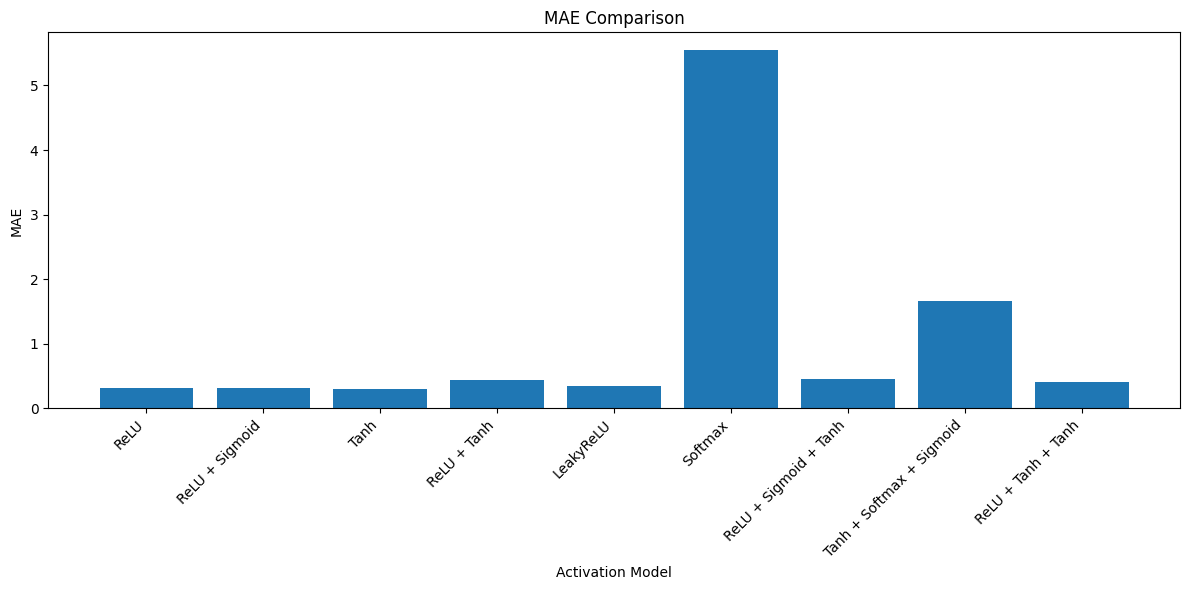

In [96]:
# 40. MAE Graph

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Activation"],
    results_df["MAE"]
)

plt.xlabel("Activation Model")
plt.ylabel("MAE")
plt.title("MAE Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

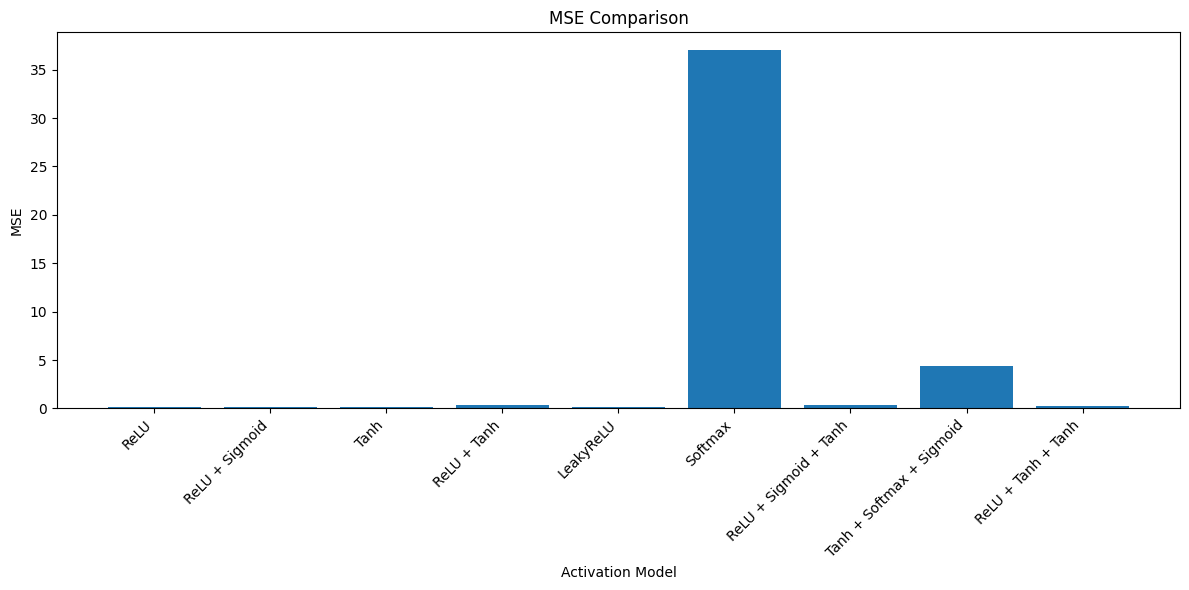

In [97]:
# 41. MSE Graph

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Activation"],
    results_df["MSE"]
)

plt.xlabel("Activation Model")
plt.ylabel("MSE")
plt.title("MSE Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

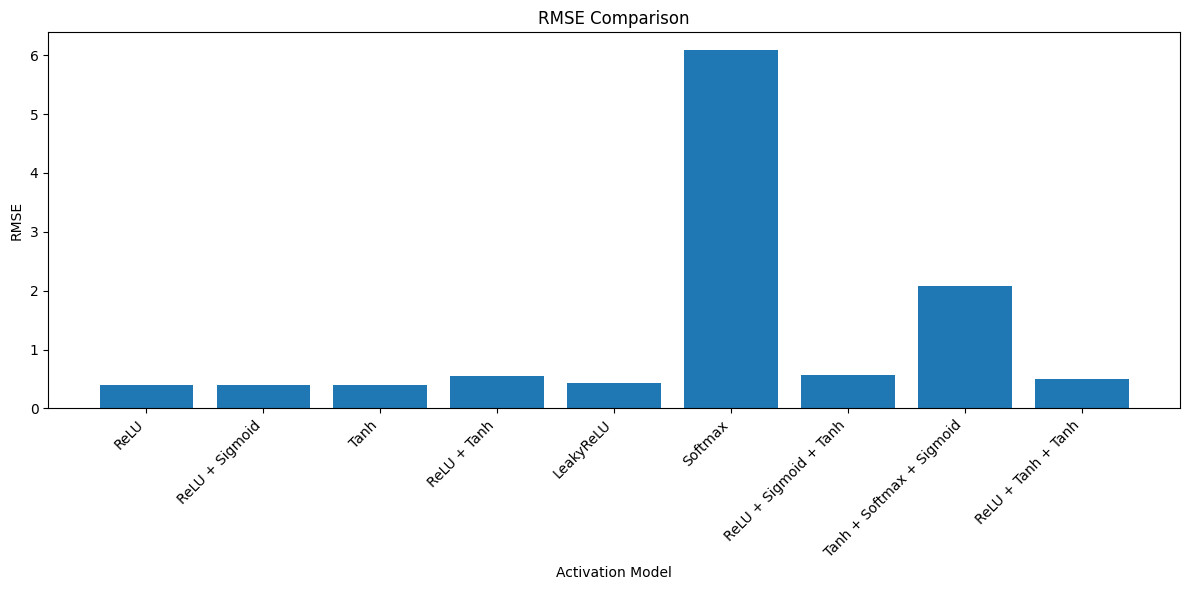

In [98]:
# 42. RMSE Graph

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Activation"],
    results_df["RMSE"]
)

plt.xlabel("Activation Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

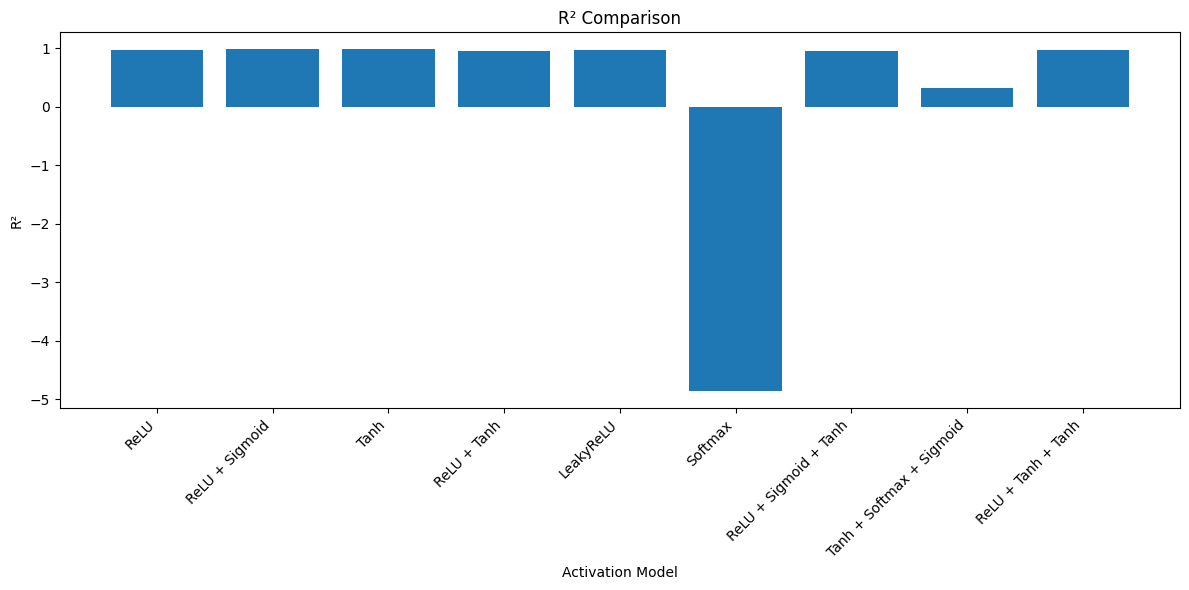

In [99]:
# 43. R² Graph

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Activation"],
    results_df["R2"]
)

plt.xlabel("Activation Model")
plt.ylabel("R²")
plt.title("R² Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

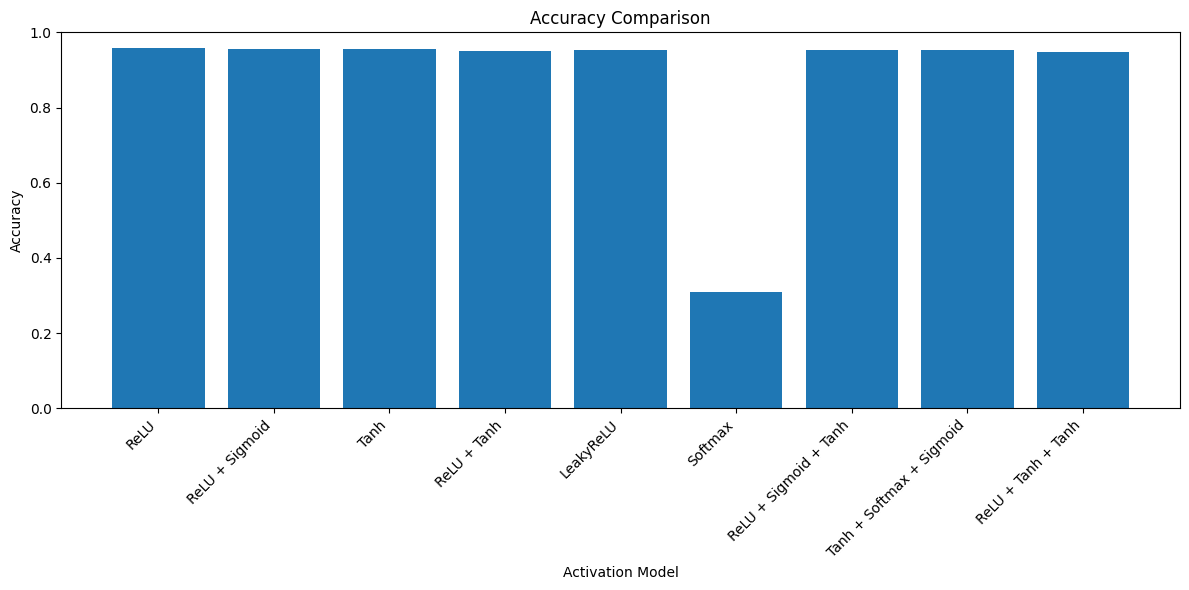

In [100]:
# 44. Accuracy Graph

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Activation"],
    results_df["Accuracy"]
)

plt.xlabel("Activation Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.ylim(0, 1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

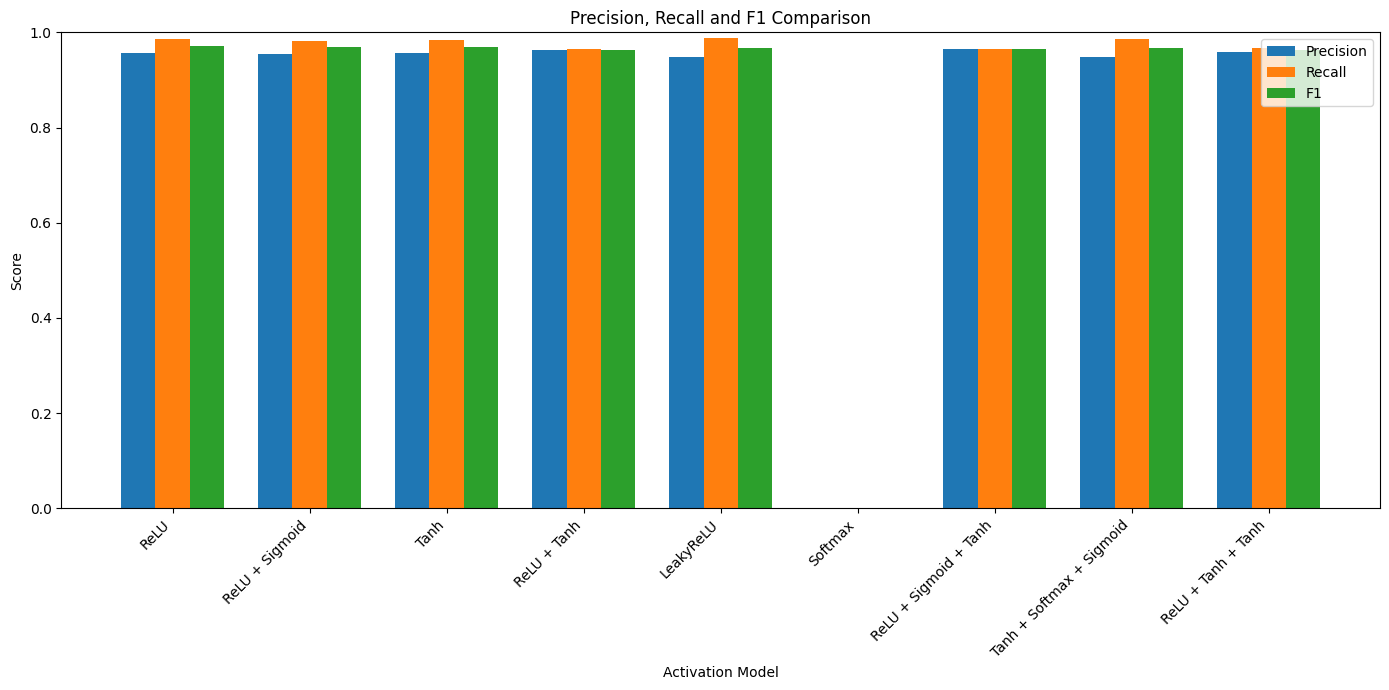

In [101]:
# 45. Precision/Recall/F1 Graph

x = np.arange(len(results_df))
width = 0.25

plt.figure(figsize=(14, 7))

plt.bar(
    x - width,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    results_df["F1"],
    width,
    label="F1"
)

plt.xlabel("Activation Model")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Comparison")

plt.xticks(
    x,
    results_df["Activation"],
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

In [102]:
# 46. Classification Table

classification_table = results_df[
    [
        "Activation",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "TP",
        "TN",
        "FP",
        "FN"
    ]
]

display(classification_table)

,Activation,Accuracy,Precision,Recall,F1,TP,TN,FP,FN
0,ReLU,0.958333,0.955931,0.985024,0.970259,2039,836,94,31
1,ReLU + Sigmoid,0.956000,0.955357,0.982126,0.968556,2033,835,95,37
2,Tanh,0.957000,0.955848,0.983092,0.969278,2035,836,94,35
3,ReLU + Tanh,0.949667,0.962410,0.964734,0.963571,1997,852,78,73
4,LeakyReLU,0.953667,0.947198,0.987923,0.967132,2045,816,114,25
5,Softmax,0.310000,0.000000,0.000000,0.000000,0,930,0,2070
6,ReLU + Sigmoid + Tanh,0.952000,0.965667,0.964734,0.965201,1997,859,71,73
7,Tanh + Softmax + Sigmoid,0.953667,0.948444,0.986473,0.967085,2042,819,111,28
8,ReLU + Tanh + Tanh,0.948667,0.958812,0.967150,0.962963,2002,844,86,68


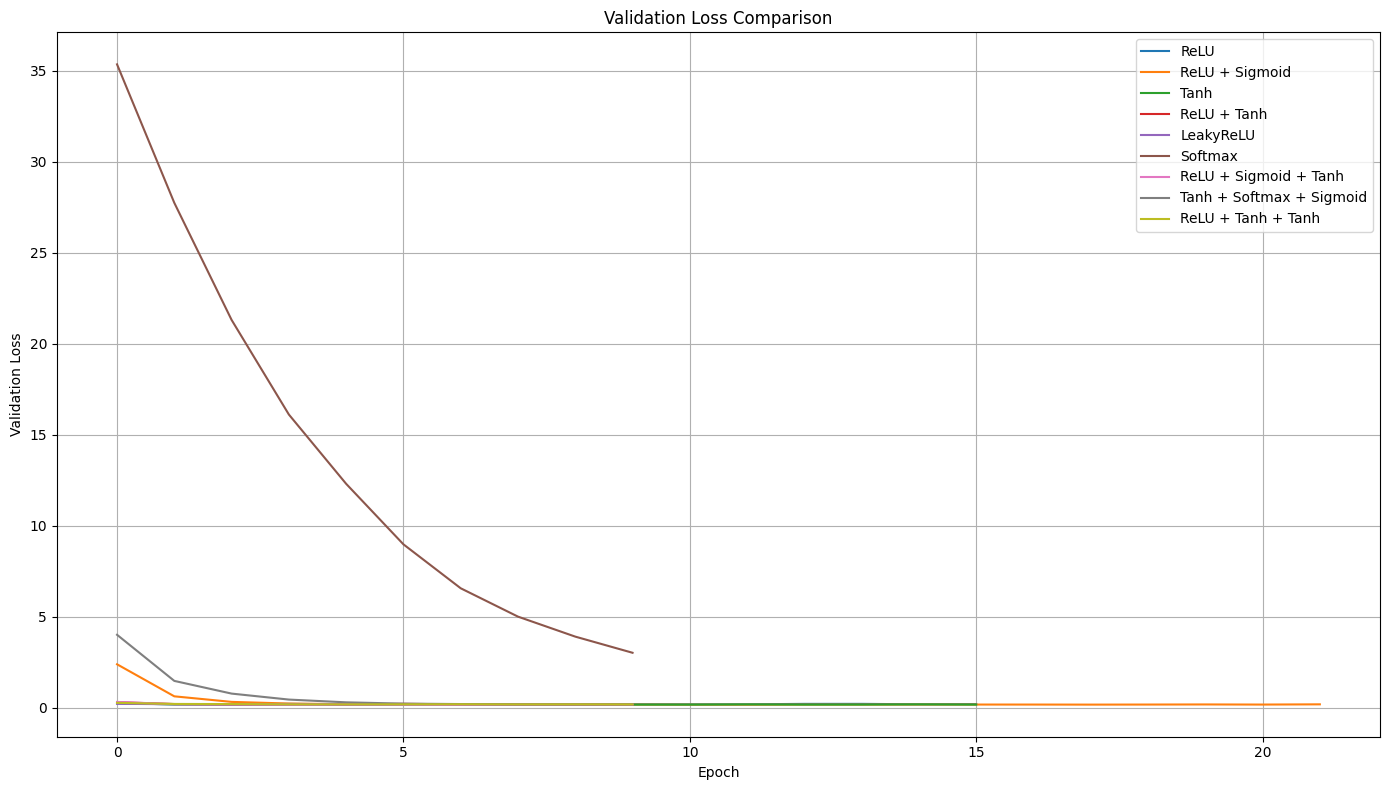

In [103]:
# 47. Validation Loss Comparison

plt.figure(figsize=(14, 8))

for model_name in activation_models:

    plt.plot(
        histories[model_name].history["val_loss"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

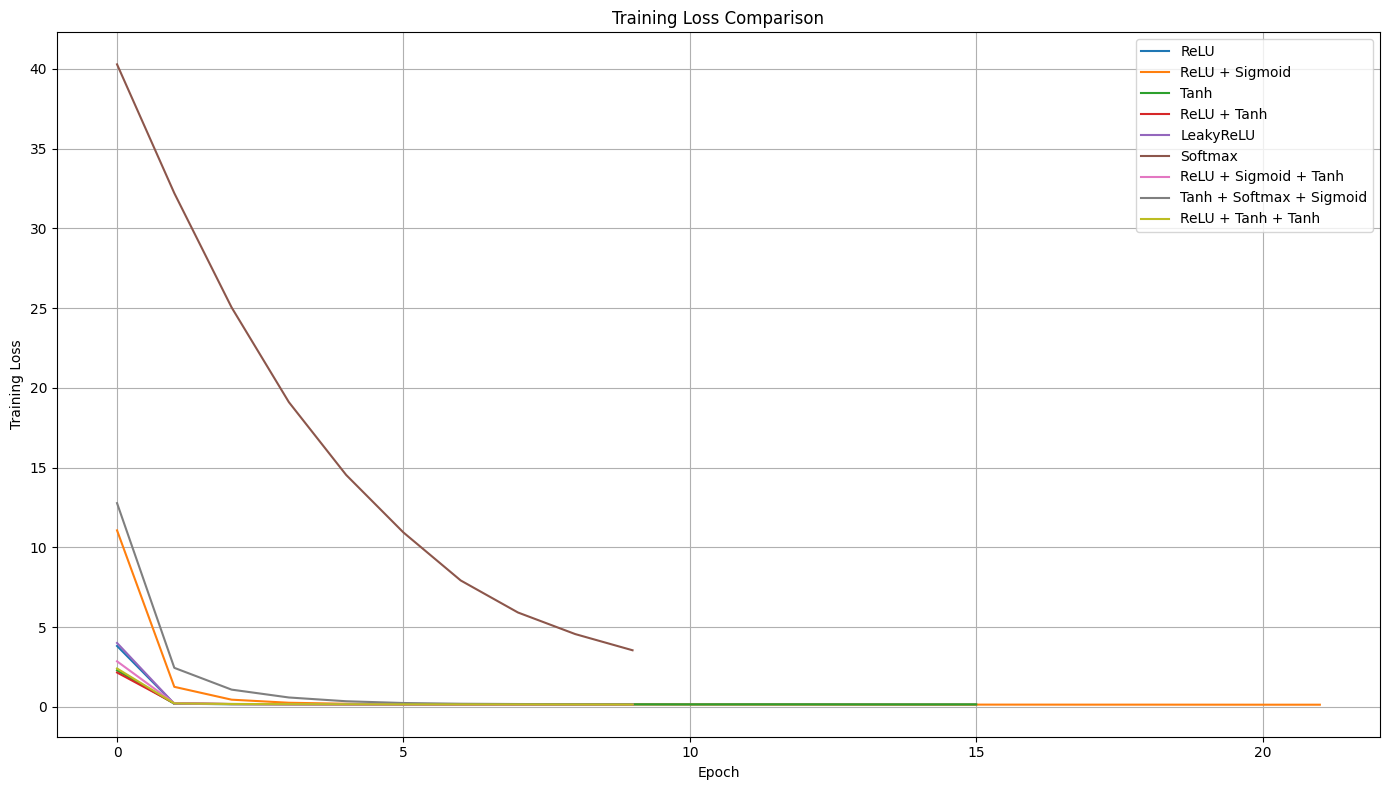

In [104]:
# 48. Training Loss Comparison

plt.figure(figsize=(14, 8))

for model_name in activation_models:

    plt.plot(
        histories[model_name].history["loss"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [105]:
# 49. Best Model Based on RMSE

best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Activation"
]

best_rmse = results_df.loc[
    results_df["RMSE"].idxmin(),
    "RMSE"
]

print("Best model according to lowest RMSE:")
print(best_model_name)

print("\nLowest RMSE:")
print(best_rmse)

Best model according to lowest RMSE:
Tanh

Lowest RMSE:
0.38956272645328965


In [106]:
# 50. Final Result Table

final_result_table = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(final_result_table)

,Activation,MAE,MSE,RMSE,R2,Accuracy,Precision,Recall,F1,TP,TN,FP,FN,Epochs,Training Time (sec)
0,Tanh,0.305409,0.151759,0.389563,0.975950,0.957000,0.955848,0.983092,0.969278,2035,836,94,35,16,18.728136
1,ReLU + Sigmoid,0.309668,0.155897,0.394837,0.975295,0.956000,0.955357,0.982126,0.968556,2033,835,95,37,22,23.748981
2,ReLU,0.318834,0.163923,0.404874,0.974023,0.958333,0.955931,0.985024,0.970259,2039,836,94,31,16,18.141526
3,LeakyReLU,0.342393,0.192139,0.438336,0.969551,0.953667,0.947198,0.987923,0.967132,2045,816,114,25,10,12.250475
4,ReLU + Tanh + Tanh,0.412460,0.255666,0.505634,0.959484,0.948667,0.958812,0.967150,0.962963,2002,844,86,68,10,10.652536
5,ReLU + Tanh,0.439691,0.302729,0.550208,0.952026,0.949667,0.962410,0.964734,0.963571,1997,852,78,73,10,12.718943
6,ReLU + Sigmoid + Tanh,0.449212,0.322445,0.567843,0.948901,0.952000,0.965667,0.964734,0.965201,1997,859,71,73,10,12.637397
7,Tanh + Softmax + Sigmoid,1.667439,4.348464,2.085297,0.310885,0.953667,0.948444,0.986473,0.967085,2042,819,111,28,10,19.294144
8,Softmax,5.544752,37.010162,6.083598,-4.865124,0.310000,0.000000,0.000000,0.000000,0,930,0,2070,10,17.937959


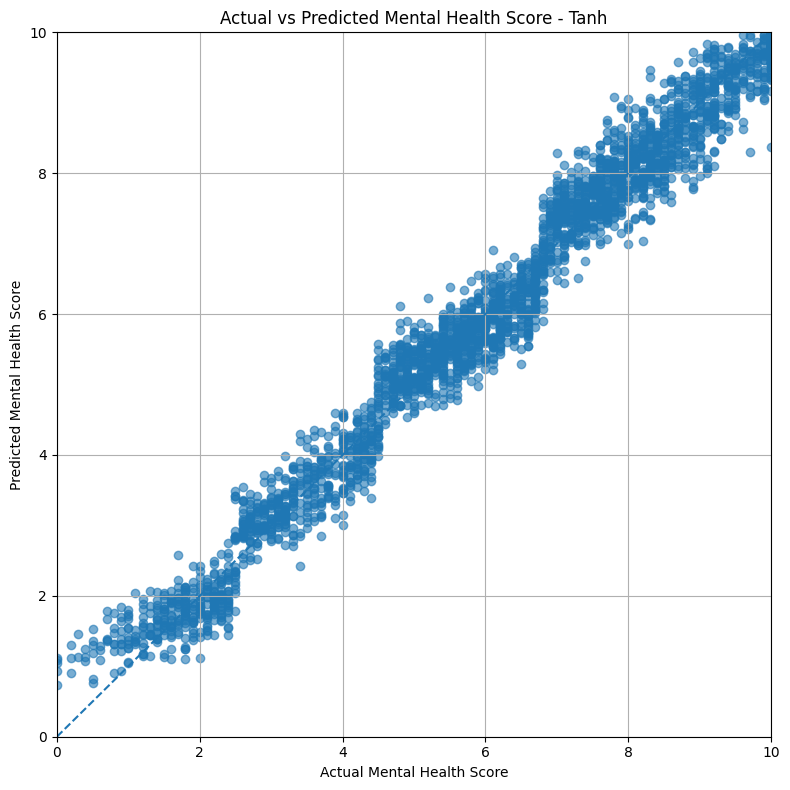

In [115]:
# 51. Actual vs Predicted

best_predictions = predictions[
    best_model_name
]

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [0, 10],
    [0, 10],
    linestyle="--"
)

plt.xlabel("Actual Mental Health Score")
plt.ylabel("Predicted Mental Health Score")

plt.title(
    "Actual vs Predicted Mental Health Score - "
    + best_model_name
)

plt.xlim(0, 10)
plt.ylim(0, 10)

plt.grid(True)

plt.tight_layout()
plt.show()

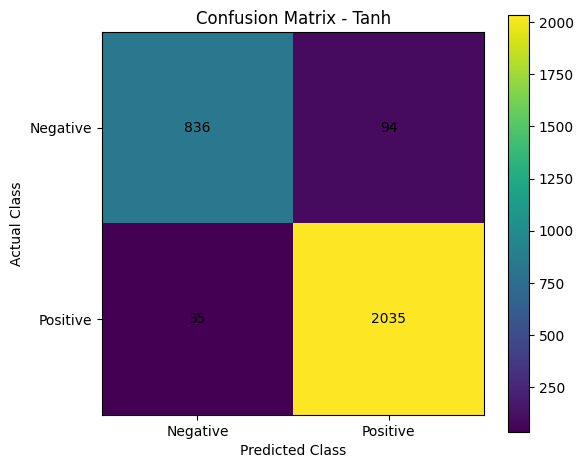

In [108]:
# 52. Best Model Confusion Matrix

best_class_predictions = predicted_classes[
    best_model_name
]

best_cm = confusion_matrix(
    y_test_class,
    best_class_predictions,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

plt.imshow(best_cm)

plt.title(
    "Confusion Matrix - " + best_model_name
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            best_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

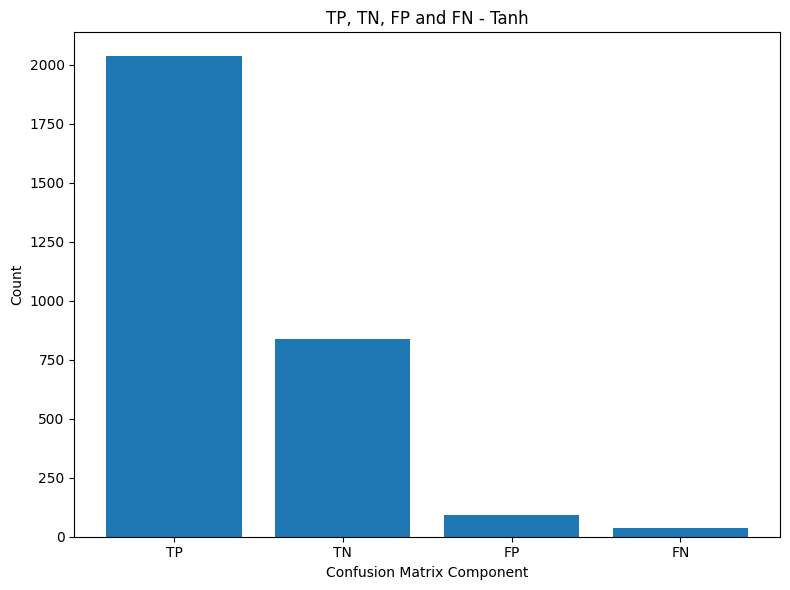

In [109]:
# 53. TP/TN/FP/FN Graph

best_confusion = confusion_results[
    best_model_name
]

confusion_names = [
    "TP",
    "TN",
    "FP",
    "FN"
]

confusion_values = [
    best_confusion["TP"],
    best_confusion["TN"],
    best_confusion["FP"],
    best_confusion["FN"]
]

plt.figure(figsize=(8, 6))

plt.bar(
    confusion_names,
    confusion_values
)

plt.xlabel("Confusion Matrix Component")
plt.ylabel("Count")

plt.title(
    "TP, TN, FP and FN - " + best_model_name
)

plt.tight_layout()
plt.show()

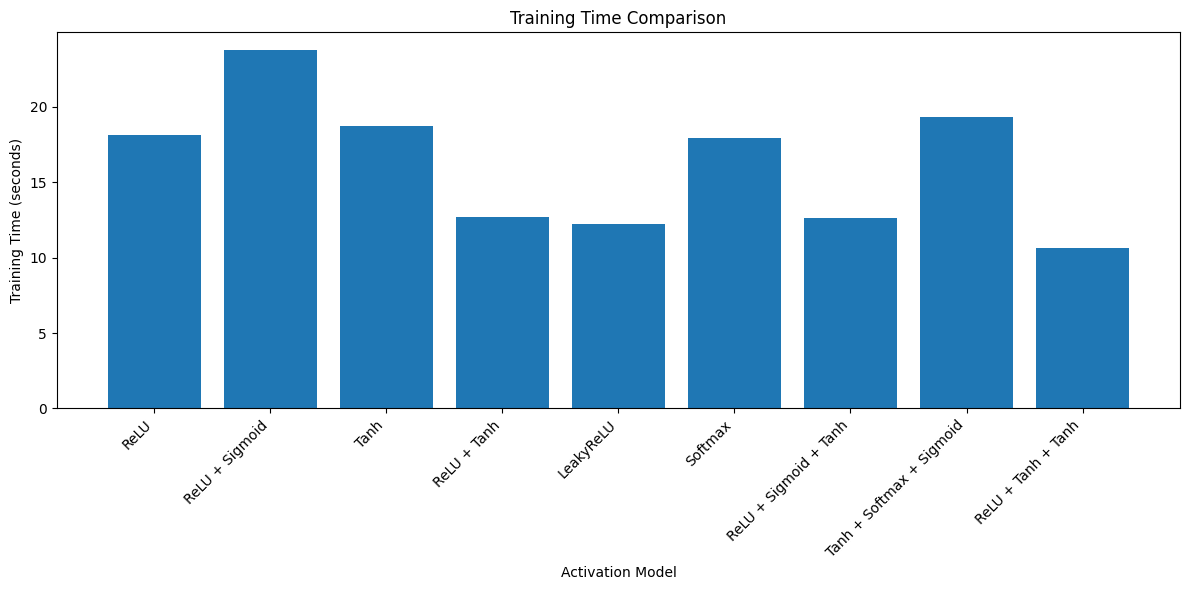

In [110]:
# 54. Training Time Graph

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Activation"],
    results_df["Training Time (sec)"]
)

plt.xlabel("Activation Model")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

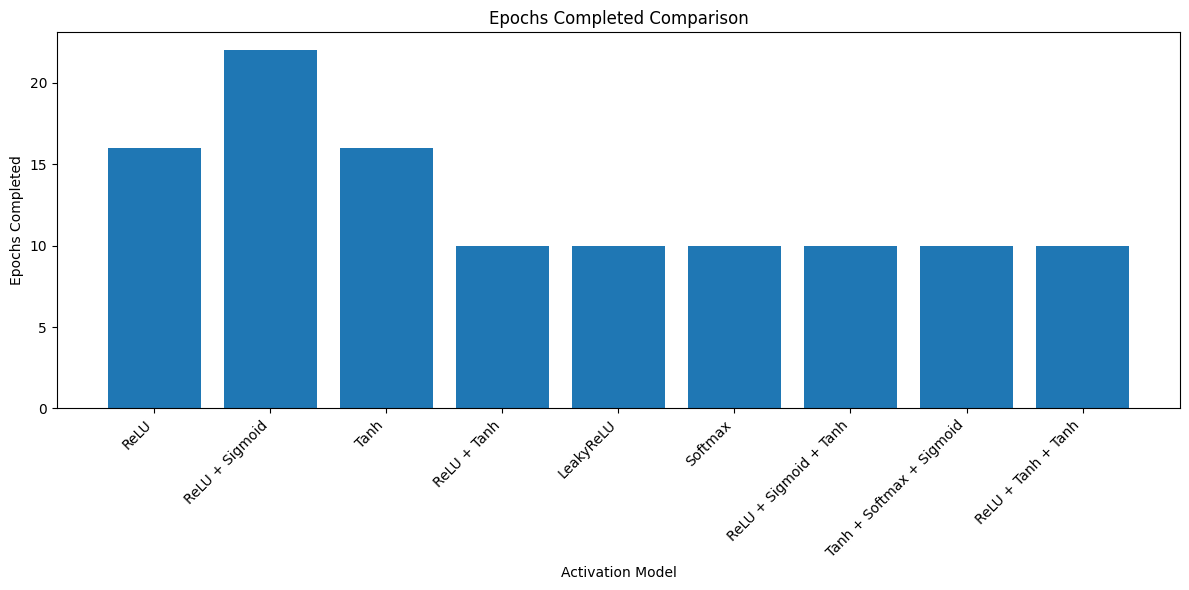

In [111]:
# 55. Epochs Completed Graph

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Activation"],
    results_df["Epochs"]
)

plt.xlabel("Activation Model")
plt.ylabel("Epochs Completed")

plt.title("Epochs Completed Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [112]:
# 56. Final Summary

best_row = results_df.loc[
    results_df["RMSE"].idxmin()
]

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print("\nBest Model Based on Lowest RMSE:")
print(best_model_name)

print("\nRegression Results:")
print("MAE  :", best_row["MAE"])
print("MSE  :", best_row["MSE"])
print("RMSE :", best_row["RMSE"])
print("R²   :", best_row["R2"])

print("\nClassification Results:")
print("Accuracy :", best_row["Accuracy"])
print("Precision:", best_row["Precision"])
print("Recall   :", best_row["Recall"])
print("F1 Score :", best_row["F1"])

print("\nConfusion Matrix:")
print("TP:", best_row["TP"])
print("TN:", best_row["TN"])
print("FP:", best_row["FP"])
print("FN:", best_row["FN"])

print("\nTraining Information:")
print("Epochs Completed:",
      best_row["Epochs"])

print("Training Time:",
      best_row["Training Time (sec)"],
      "seconds")

print("\n" + "=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

FINAL SUMMARY

Best Model Based on Lowest RMSE:
Tanh

Regression Results:
MAE  : 0.3054085969924927
MSE  : 0.15175911784172058
RMSE : 0.38956272645328965
R²   : 0.9759502410888672

Classification Results:
Accuracy : 0.957
Precision: 0.9558478158759981
Recall   : 0.9830917874396136
F1 Score : 0.9692783996189569

Confusion Matrix:
TP: 2035
TN: 836
FP: 94
FN: 35

Training Information:
Epochs Completed: 16
Training Time: 18.72813630104065 seconds

PROJECT COMPLETED
